# **프로젝트 : KoChatGPT 업그레이드 하기**

**프로젝트의 목표**

*   기존 데이터셋을 추가로 정제하는 방법은 무엇인가?
*   KoChatGPT 소스코드를 바탕으로 현재 상황에서 적합한 모델 개선 전략은 무엇인가?
*   SFT(Supervised Fine-Tuning)와 RM(Reward Model)을 통한 결과물을 비교하는데 적합한 정량적 및 정성적 분석 방법은 무엇인가?



**적용 전략**

*   기존 데이터셋 추가 정제 및 증강
*   foundation model 교체**  
   - 기본값: `skt/ko-gpt-trinity-1.2B-v0.5`
   - 비교용 baseline: `skt/kogpt2-base-v2`
*   SFT 학습 + RM 학습 + 디코딩 하이퍼파라미터 서치 :
   - 좋은 예시 학습-답변 품질 평가-출력 방식 개선을 통한 답변 결과 개선
   - Top-p 등의 방법을 통한 출력 방법 서치
*   정량적 및 정성적 평가
   - BLEU : 단어와 구문이 얼마나 비슷한지 보는 지표
   - ROUGE-1 / ROUGE-2 / ROUGE-L : 단어의 겹침 표현 정도를 보는 지표
   - Reward Model 평균 점수 : 사람이 봤을때 답변이 얼마나 좋은 평가하는 지표
   - RM pairwise accuracy : 두 답변 중 RM이 더 좋은 답변을 선택하는지 보는 정확도 지표
   - 샘플 qualitative 비교 : 실제 예시를 샘플링하여 비교

**0. 환경설정**

In [ ]:
# 패키지 설치
import sys, subprocess

subprocess.run(
    [
        sys.executable, "-m", "pip", "install", "-q", "-U",
        "transformers", "datasets", "accelerate", "peft", "trl",
        "bitsandbytes", "evaluate", "sacrebleu", "rouge-score",
        "sentencepiece", "pandas", "numpy", "scikit-learn",
        "matplotlib", "seaborn", "tqdm"
    ],
    check=True,
)
print("packages installed")

packages installed


In [ ]:

import os
import re
import gc
import json
import math
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

from datasets import Dataset
import evaluate
from sacrebleu import corpus_bleu

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
    default_data_collator,
    set_seed,
)

from peft import (
    LoraConfig,
    PeftModel,
    get_peft_model,
    prepare_model_for_kbit_training,
)

warnings.filterwarnings("ignore")

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("cuda capability:", torch.cuda.get_device_capability(0))

device: cuda
gpu: Tesla T4
cuda capability: (7, 5)


**1. 실행 설정**

- 기본 foundation model은 `skt/ko-gpt-trinity-1.2B-v0.5`
- baseline 비교는 `skt/kogpt2-base-v2`

In [ ]:
# 실험 설정
QUICK_MODE = True          # 빠른 검증용
RUN_PPO = False            # 기본 False
ALLOW_FALLBACK_TO_KOGPT2 = False

BASELINE_MODEL_NAME = "skt/kogpt2-base-v2"
FOUNDATION_MODEL_NAME = "skt/ko-gpt-trinity-1.2B-v0.5"

RESULTS_DIR = Path("/content/kochatgpt_project_outputs")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MAX_LENGTH = 384 if QUICK_MODE else 512
SFT_EPOCHS = 1 if QUICK_MODE else 2
RM_EPOCHS = 1 if QUICK_MODE else 1
SFT_BATCH_SIZE = 1
RM_BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 8 if QUICK_MODE else 16
EVAL_SAMPLE_SIZE = 40 if QUICK_MODE else 200
GEN_MAX_NEW_TOKENS = 96 if QUICK_MODE else 128

print("RESULTS_DIR =", RESULTS_DIR)

RESULTS_DIR = /content/kochatgpt_project_outputs


**2. 데이터 업로드 및 로드**

In [ ]:
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

def maybe_upload_files():
    if IN_COLAB:
        print("필요한 파일이 없으면 업로드 창이 열립니다.")
        return files.upload()
    return {}

uploaded = maybe_upload_files()
list(uploaded.keys())[:5]

필요한 파일이 없으면 업로드 창이 열립니다.


Saving kochatgpt_1_SFT.jsonl to kochatgpt_1_SFT (1).jsonl
Saving kochatgpt_2_RM.jsonl to kochatgpt_2_RM (1).jsonl
Saving kochatgpt_3_PPO.jsonl to kochatgpt_3_PPO (1).jsonl


['kochatgpt_1_SFT (1).jsonl',
 'kochatgpt_2_RM (1).jsonl',
 'kochatgpt_3_PPO (1).jsonl']

In [ ]:
def resolve_file(candidates):
    for name in candidates:
        if Path(name).exists():
            return Path(name)
    for p in Path(".").glob("*.jsonl"):
        if p.name in candidates:
            return p
    return None

def load_data(path):
    with open(path, "r", encoding="utf-8-sig") as f:
        text = f.read().strip()

    # 먼저 전체 JSON으로 시도
    try:
        data = json.loads(text)
        if isinstance(data, list):
            return data
        return [data]
    except json.JSONDecodeError:
        pass

    # 실패하면 JSONL로 시도
    rows = []
    for i, line in enumerate(text.splitlines(), 1):
        line = line.strip()
        if line:
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"{path}의 {i}번째 줄 JSON 오류: {line[:100]}")
                raise e
    return rows

SFT_FILE = resolve_file(["kochatgpt_1_SFT.jsonl"])
RM_FILE = resolve_file(["kochatgpt_1_RM.jsonl", "kochatgpt_2_RM.jsonl"])
PPO_FILE = resolve_file(["kochatgpt_1_PPO.jsonl", "kochatgpt_3_PPO.jsonl"])

print("SFT_FILE:", SFT_FILE)
print("RM_FILE :", RM_FILE)
print("PPO_FILE:", PPO_FILE)

assert SFT_FILE is not None, "SFT 파일을 찾지 못했습니다."
assert RM_FILE is not None, "RM 파일을 찾지 못했습니다."
assert PPO_FILE is not None, "PPO 파일을 찾지 못했습니다."

sft_rows = load_data(SFT_FILE)
rm_rows = load_data(RM_FILE)
ppo_rows = load_data(PPO_FILE)

print("raw sizes -> SFT:", len(sft_rows), "RM:", len(rm_rows), "PPO:", len(ppo_rows))

SFT_FILE: kochatgpt_1_SFT.jsonl
RM_FILE : kochatgpt_2_RM.jsonl
PPO_FILE: kochatgpt_3_PPO.jsonl
raw sizes -> SFT: 12000 RM: 10220 PPO: 12000


In [ ]:
sft_df = pd.DataFrame(sft_rows)
rm_df = pd.DataFrame(rm_rows)
ppo_df = pd.DataFrame(ppo_rows)

print("SFT columns:", sft_df.columns.tolist())
print("RM columns :", rm_df.columns.tolist())
print("PPO columns:", ppo_df.columns.tolist())

display(sft_df.head(2))
display(rm_df.head(2))
display(ppo_df.head(2))

SFT columns: ['prompt', 'completion', 'tokens']
RM columns : ['prompt', 'completion_0', 'completion_1', 'completion_2', 'ranking']
PPO columns: ['prompt']


,prompt,completion,tokens
0,불고기용 고기 한우에요?,"'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하...",193
1,쓰던 앱이 유료로 전환됐어,"'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 ...",288


,prompt,completion_0,completion_1,completion_2,ranking
0,"번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독...",Allow me to answer your question. I know that ...,번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.,라이언에게 말했다.,"[2, 1, 0]"
1,개포주공아파트는 몇 단지로 이루어져 있나?,개포주공아파트는 다섯 단지로 이루어져 있습니다.,이날 목송에서 구글상위노,개포주공아파트는 총 27개 단지로 이루어져 있습니다.,"[2, 0, 1]"


,prompt
0,"번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독..."
1,개포주공아파트는 몇 단지로 이루어져 있나?


**3. 데이터 EDA**

*   데이터 구성

    *   SFT 데이터셋: 12,000개
    *   RM 데이터셋: 10,220개
    *   PPO 데이터셋: 12,000개

*   길이 분포 및 중복도 분석

    *   평균 문자 수: 22.18자
    *   중앙값 문자 수: 19자
    *   평균 단어 수: 5.53개
    *   중복 비율: 0.45%
    *   평균 한글 비율: 0.754
    *   평균 완성도 점수: 0.827

    *   전체 prompt 길이는 비교적 짧은 편이며, 중복 비율은 매우 낮아 단순 중복 데이터가 과도하게 많지는 않음을 확인
    *   한글 비율이 75% 수준으로 한국어 중심 데이터이지만, 일부 영문/기타 문자열이 섞여 있음

*   도메인 분포 분석

    *   기타: 9,030개
    *   지식/상식: 2,164개
    *   조언/상담: 412개
    *   일상/감정: 337개
    *   업무/학습: 57개

    *   데이터가 특정 한 도메인에만 집중되어 있었음

*   문체 및 문장 완성도 분석(SFT completion)

    *   존댓말: 9,610개
    *   기타: 2,352개
    *   구어체/혼합: 38개

    *   전체 응답은 대체로 높임말 중심이며 completion의 완성도 점수의 평균이 0.9758이라는 점에서 완성도가 높다고 할 수 있음

In [ ]:
def normalize_space(text):
    text = "" if text is None else str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def contains_korean_ratio(text):
    text = normalize_space(text)
    if not text:
        return 0.0
    total = len(text)
    kor = len(re.findall(r"[가-힣]", text))
    return kor / max(total, 1)

def classify_domain(text):
    text = normalize_space(text).lower()
    rules = {
        "일상/감정": ["우울", "힘들", "사랑", "여친", "남친", "술", "외로", "기분", "스트레스"],
        "지식/상식": ["무엇", "언제", "어디", "왜", "누구", "설명", "의미", "정의", "차이", "역사"],
        "조언/상담": ["어떻게", "방법", "추천", "도와", "해결", "조언", "해야", "좋을까"],
        "업무/학습": ["공부", "과제", "논문", "코드", "모델", "학습", "분석", "요약"],
    }
    for label, kws in rules.items():
        if any(kw in text for kw in kws):
            return label
    return "기타"

def detect_style(text):
    text = normalize_space(text)
    if re.search(r"(습니다|세요|드립니다|합니다)([.!?…]|$)", text):
        return "존댓말"
    if re.search(r"(야|해|해요|지|네)([.!?…]|$)", text):
        return "구어체/혼합"
    return "기타"

def completeness_score(text):
    text = normalize_space(text)
    if not text:
        return 0
    score = 0
    if text[-1] in ".!?…다요":
        score += 1
    if len(text) >= 10:
        score += 1
    if "�" not in text:
        score += 1
    return score / 3.0

def basic_eda(df, text_cols, name="dataset"):
    local = df.copy()
    for c in text_cols:
        local[c] = local[c].fillna("").astype(str).map(normalize_space)

    combined = local[text_cols[0]]
    lengths = combined.str.len()
    word_lengths = combined.str.split().map(len)

    summary = {
        "dataset": name,
        "rows": len(local),
        "char_len_mean": lengths.mean(),
        "char_len_median": lengths.median(),
        "word_len_mean": word_lengths.mean(),
        "dup_ratio": 1 - (combined.nunique() / max(len(combined), 1)),
        "kor_ratio_mean": combined.map(contains_korean_ratio).mean(),
        "complete_mean": combined.map(completeness_score).mean(),
    }
    return local, pd.DataFrame([summary])

sft_eda_df, sft_summary = basic_eda(sft_df, ["prompt", "completion"], "SFT")
ppo_eda_df, ppo_summary = basic_eda(ppo_df, ["prompt"], "PPO")

display(pd.concat([sft_summary, ppo_summary], ignore_index=True))

,dataset,rows,char_len_mean,char_len_median,word_len_mean,dup_ratio,kor_ratio_mean,complete_mean
0,SFT,12000,22.175667,19.0,5.532583,0.0045,0.753611,0.826639
1,PPO,12000,22.175667,19.0,5.532583,0.0045,0.753611,0.826639


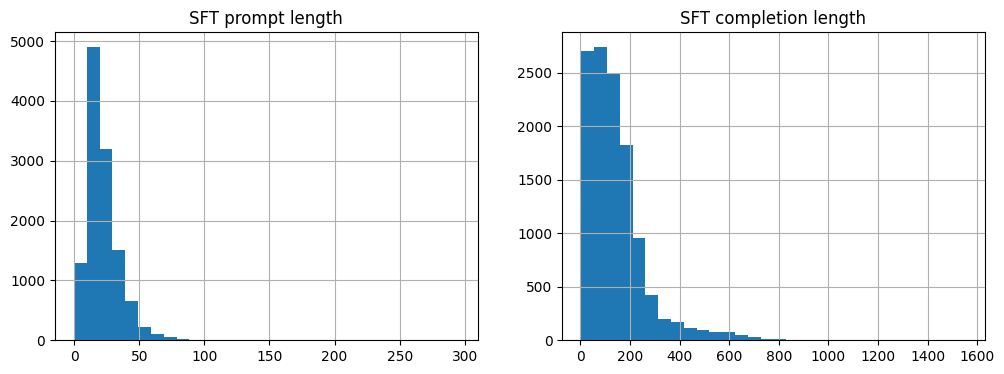

,count
domain,
기타,9030
지식/상식,2164
조언/상담,412
일상/감정,337
업무/학습,57


,count
style,
존댓말,9610
기타,2352
구어체/혼합,38


,complete_score
count,12000.000000
mean,0.975778
std,0.088960
min,0.333333
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
# SFT 길이, 도메인, 문체 분석
tmp = sft_df.copy()
tmp["prompt"] = tmp["prompt"].fillna("").astype(str).map(normalize_space)
tmp["completion"] = tmp["completion"].fillna("").astype(str).map(normalize_space)
tmp["prompt_len"] = tmp["prompt"].str.len()
tmp["completion_len"] = tmp["completion"].str.len()
tmp["domain"] = tmp["prompt"].map(classify_domain)
tmp["style"] = tmp["completion"].map(detect_style)
tmp["complete_score"] = tmp["completion"].map(completeness_score)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tmp["prompt_len"].hist(ax=axes[0], bins=30)
axes[0].set_title("SFT prompt length")
tmp["completion_len"].hist(ax=axes[1], bins=30)
axes[1].set_title("SFT completion length")
plt.show()

display(tmp["domain"].value_counts().to_frame("count"))
display(tmp["style"].value_counts().to_frame("count"))
display(tmp["complete_score"].describe().to_frame("complete_score"))

**4. 데이터 정제 및 증강**

- 중복 제거
- 공백, 제어문자, 깨진 문자 정리
- 지나치게 짧거나 비정상적인 샘플 제거
- completion 끝맺음 보정
- 데이터셋 크기 감소를 막기 위해 instruction template augmentation(같은 내용의 데이터 내에서 지시문(instruction) 표현만 여러 방식으로 바꿔서 늘리는 방법) 적용

In [ ]:

def clean_text(text):
    text = "" if text is None else str(text)
    text = text.replace("\u200b", " ").replace("\xa0", " ")
    text = re.sub(r"[\r\t]+", " ", text)
    text = re.sub(r" +", " ", text)
    text = text.strip()
    text = text.replace("“", '"').replace("”", '"').replace("’", "'").replace("‘", "'")
    text = re.sub(r"[ ]+([,.!?…])", r"\1", text)
    text = re.sub(r"([.!?…])\1{2,}", r"\1\1", text)
    return text

def finalize_completion(text):
    text = clean_text(text)
    if not text:
        return text
    if text[-1] not in ".!?…다요":
        text += "."
    return text

def valid_prompt(text):
    text = clean_text(text)
    if len(text) < 2:
        return False
    if contains_korean_ratio(text) < 0.15:
        return False
    return True

def valid_completion(text):
    text = finalize_completion(text)
    if len(text) < 5:
        return False
    return True

def augment_prompt(prompt):
    prompt = clean_text(prompt)
    variants = [
        prompt,
        f"다음 질문에 한국어로 친절하고 도움이 되게 답변하세요.\n질문: {prompt}\n답변:",
        f"### 사용자 질문\n{prompt}\n\n### 어시스턴트 답변\n",
    ]
    # 중복 제거
    return list(dict.fromkeys(variants))

def augment_rm_prompt(prompt):
    prompt = clean_text(prompt)
    variants = [
        prompt,
        f"질문: {prompt}\n답변:",
    ]
    return list(dict.fromkeys(variants))

def clean_and_augment_sft(df):
    rows = []
    for _, row in df.iterrows():
        prompt = clean_text(row["prompt"])
        completion = finalize_completion(row["completion"])
        if not (valid_prompt(prompt) and valid_completion(completion)):
            continue
        for ap in augment_prompt(prompt):
            rows.append({"prompt": ap, "completion": completion})
    out = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)
    return out

def clean_ppo(df):
    rows = []
    for _, row in df.iterrows():
        prompt = clean_text(row["prompt"])
        if valid_prompt(prompt):
            for ap in augment_rm_prompt(prompt):
                rows.append({"prompt": ap})
    return pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)

clean_sft_df = clean_and_augment_sft(sft_df)
clean_ppo_df = clean_ppo(ppo_df)

print("SFT raw -> cleaned/aug:", len(sft_df), "->", len(clean_sft_df))
print("PPO raw -> cleaned/aug:", len(ppo_df), "->", len(clean_ppo_df))
display(clean_sft_df.head(3))

SFT raw -> cleaned/aug: 12000 -> 35976
PPO raw -> cleaned/aug: 12000 -> 23880


,prompt,completion
0,불고기용 고기 한우에요?,"'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하..."
1,다음 질문에 한국어로 친절하고 도움이 되게 답변하세요.\n질문: 불고기용 고기 한우...,"'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하..."
2,### 사용자 질문\n불고기용 고기 한우에요?\n\n### 어시스턴트 답변\n,"'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하..."


In [ ]:
def rm_to_pairwise_df(df):
    # 이미 chosen/rejected 포맷이면 그대로 사용
    if {"prompt", "chosen", "rejected"}.issubset(df.columns):
        out = df[["prompt", "chosen", "rejected"]].copy()
        out["prompt"] = out["prompt"].map(clean_text)
        out["chosen"] = out["chosen"].map(finalize_completion)
        out["rejected"] = out["rejected"].map(finalize_completion)
        out = out[
            out["prompt"].map(valid_prompt)
            & out["chosen"].map(valid_completion)
            & out["rejected"].map(valid_completion)
            & (out["chosen"] != out["rejected"])
        ].drop_duplicates().reset_index(drop=True)
        return out

    required = {"prompt", "completion_0", "completion_1", "completion_2", "ranking"}
    assert required.issubset(df.columns), f"RM 데이터 컬럼이 예상과 다릅니다. 필요 컬럼: {required}"

    rows = []
    for _, row in df.iterrows():
        prompt = clean_text(row["prompt"])
        if not valid_prompt(prompt):
            continue

        completions = {
            0: finalize_completion(row["completion_0"]),
            1: finalize_completion(row["completion_1"]),
            2: finalize_completion(row["completion_2"]),
        }
        ranking = row["ranking"]

        # ranking은 [best_idx, middle_idx, worst_idx] 형태라고 가정
        try:
            ranking = list(ranking)
        except Exception:
            continue

        if sorted(ranking) != [0, 1, 2]:
            continue

        ordered = ranking[:]  # best -> worst
        pairs = [(ordered[0], ordered[1]), (ordered[0], ordered[2]), (ordered[1], ordered[2])]

        for chosen_idx, rejected_idx in pairs:
            chosen = completions[chosen_idx]
            rejected = completions[rejected_idx]
            if chosen != rejected and valid_completion(chosen) and valid_completion(rejected):
                for ap in augment_rm_prompt(prompt):
                    rows.append(
                        {
                            "prompt": ap,
                            "chosen": chosen,
                            "rejected": rejected,
                        }
                    )

    out = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)
    return out

pairwise_rm_df = rm_to_pairwise_df(rm_df)
print("RM raw -> pairwise cleaned/aug:", len(rm_df), "->", len(pairwise_rm_df))
display(pairwise_rm_df.head(3))

RM raw -> pairwise cleaned/aug: 10220 -> 59990


,prompt,chosen,rejected
0,"번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독...",라이언에게 말했다.,번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.
1,"질문: 번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들...",라이언에게 말했다.,번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.
2,"번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독...",라이언에게 말했다.,Allow me to answer your question. I know that ...


In [ ]:
# train과 valid split
train_sft_df, valid_sft_df = train_test_split(clean_sft_df, test_size=0.1, random_state=SEED, shuffle=True)
train_rm_df, valid_rm_df = train_test_split(pairwise_rm_df, test_size=0.1, random_state=SEED, shuffle=True)
train_ppo_df, valid_ppo_df = train_test_split(clean_ppo_df, test_size=0.1, random_state=SEED, shuffle=True)

if QUICK_MODE:
    train_sft_df = train_sft_df.sample(min(len(train_sft_df), 3000), random_state=SEED)
    valid_sft_df = valid_sft_df.sample(min(len(valid_sft_df), 200), random_state=SEED)
    train_rm_df = train_rm_df.sample(min(len(train_rm_df), 4000), random_state=SEED)
    valid_rm_df = valid_rm_df.sample(min(len(valid_rm_df), 300), random_state=SEED)
    train_ppo_df = train_ppo_df.sample(min(len(train_ppo_df), 2000), random_state=SEED)
    valid_ppo_df = valid_ppo_df.sample(min(len(valid_ppo_df), 200), random_state=SEED)

print("train_sft:", len(train_sft_df), "valid_sft:", len(valid_sft_df))
print("train_rm :", len(train_rm_df), "valid_rm :", len(valid_rm_df))
print("train_ppo:", len(train_ppo_df), "valid_ppo:", len(valid_ppo_df))

train_sft: 3000 valid_sft: 200
train_rm : 4000 valid_rm : 300
train_ppo: 2000 valid_ppo: 200


**5. 공통 유틸리티**

In [ ]:
PROMPT_TEMPLATE = "### 사용자 질문\n{prompt}\n\n### 어시스턴트 답변\n"

def format_prompt(prompt):
    return PROMPT_TEMPLATE.format(prompt=clean_text(prompt))

def release_memory(*objs):
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def get_quant_config():
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

def load_tokenizer(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    return tokenizer

def infer_lora_target_modules(model):
    candidates = {
        "c_attn", "c_proj", "c_fc",
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    }
    found = []
    for name, _ in model.named_modules():
        last = name.split(".")[-1]
        if last in candidates:
            found.append(last)
    found = sorted(set(found))
    return found if found else ["c_attn", "c_proj", "c_fc"]

def load_causal_lm_for_training(model_name):
    tokenizer = load_tokenizer(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=get_quant_config(),
        device_map="auto",
        trust_remote_code=True,
    )
    model.config.use_cache = False
    model.config.pad_token_id = tokenizer.pad_token_id
    model = prepare_model_for_kbit_training(model)
    try:
        model.gradient_checkpointing_enable()
    except Exception:
        pass
    targets = infer_lora_target_modules(model)
    print("LoRA target modules:", targets)
    peft_cfg = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=targets,
    )
    model = get_peft_model(model, peft_cfg)
    model.print_trainable_parameters()
    return model, tokenizer

def load_rm_model_for_training(model_name):
    tokenizer = load_tokenizer(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=1,
        quantization_config=get_quant_config(),
        device_map="auto",
        trust_remote_code=True,
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    model = prepare_model_for_kbit_training(model)
    try:
        model.gradient_checkpointing_enable()
    except Exception:
        pass
    targets = infer_lora_target_modules(model)
    print("RM LoRA target modules:", targets)
    peft_cfg = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        task_type="SEQ_CLS",
        target_modules=targets,
    )
    model = get_peft_model(model, peft_cfg)
    model.print_trainable_parameters()
    return model, tokenizer

**6. Baseline(기존 KoGPT2) 응답 확인**

In [ ]:

baseline_tokenizer = load_tokenizer(BASELINE_MODEL_NAME)

baseline_model = AutoModelForCausalLM.from_pretrained(
    BASELINE_MODEL_NAME,
    quantization_config=get_quant_config(),
    device_map="auto",
    trust_remote_code=True,
)
baseline_model.config.pad_token_id = baseline_tokenizer.pad_token_id
baseline_model.eval()

def generate_response(model, tokenizer, prompt, generation_kwargs=None):
    generation_kwargs = generation_kwargs or {}
    prompt_text = format_prompt(prompt)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=generation_kwargs.get("max_new_tokens", GEN_MAX_NEW_TOKENS),
            do_sample=generation_kwargs.get("do_sample", True),
            top_k=generation_kwargs.get("top_k", 50),
            top_p=generation_kwargs.get("top_p", 0.92),
            temperature=generation_kwargs.get("temperature", 0.8),
            repetition_penalty=generation_kwargs.get("repetition_penalty", 1.1),
            num_beams=generation_kwargs.get("num_beams", 1),
            num_return_sequences=generation_kwargs.get("num_return_sequences", 1),
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    prompt_len = inputs["input_ids"].shape[1]
    if generation_kwargs.get("num_return_sequences", 1) == 1:
        return tokenizer.decode(outputs[0][prompt_len:], skip_special_tokens=True).strip()

    decoded = []
    for seq in outputs:
        decoded.append(tokenizer.decode(seq[prompt_len:], skip_special_tokens=True).strip())
    return decoded

sample_prompts = [
    "요즘 너무 지치는데 어떻게 마음을 다잡을 수 있을까?",
    "콜드 스타트 문제가 무엇인지 쉽게 설명해줘.",
    "강화학습의 policy를 중학생도 이해하게 설명해줘."
]

for p in sample_prompts:
    print("\n[Prompt]", p)
    print("[Baseline]", generate_response(baseline_model, baseline_tokenizer, p))

config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[Prompt] 요즘 너무 지치는데 어떻게 마음을 다잡을 수 있을까?
[Baseline] +�������������
▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁

[Prompt] 콜드 스타트 문제가 무엇인지 쉽게 설명해줘.
[Baseline] +�q�o�s.#▁오늘▁밤은▁더워지겠다.
오늘의▁휴일은▁역시나▁좀▁쉬는▁거▁같습니다.
지금도▁너무▁무더워서▁잠▁못▁드는▁분들도▁계시죠.
아침에▁일어나서▁이렇게▁말씀을▁드리고▁싶네요.
아침에는▁땀이▁많이▁나지만▁낮에도▁무척▁덥습니다.
내일▁아침도▁여전히▁더울▁텐데요,
점심시간에▁제주를▁제외하고는▁대부분▁지역에서▁10도가량▁크게▁오르겠고요,
중

[Prompt] 강화학습의 policy를 중학생도 이해하게 설명해줘.
[Baseline] u�
#▁#▁#▁#2017.08.15~▁(▁수)
2015년▁1월▁1일▁~▁2월▁25일▁(▁일▁)▁-▁2017년▁7월▁2일▁~▁8월▁8일▁(▁일요일▁)▁-▁2018년▁7월▁11일▁~▁10월▁21일▁(▁금▁)▁-▁2019년▁9월▁24일▁~▁11월▁22일▁(▁토▁)▁-▁2020년▁1월▁23일▁(▁일▁)▁-▁2019년▁9월▁13일▁~▁12월▁3일▁(▁토▁)▁-▁2021년▁3월▁9일▁~▁4월▁14일▁(▁일▁)▁-▁2022년▁6월


**7. SFT 데이터셋 토크나이즈**

completion 부분만 loss가 걸리도록 labels를 구성

In [ ]:

def build_sft_features(df, tokenizer, max_length=MAX_LENGTH):
    records = []
    for _, row in df.iterrows():
        prompt_ids = tokenizer(format_prompt(row["prompt"]), add_special_tokens=False)["input_ids"]
        answer_ids = tokenizer(finalize_completion(row["completion"]) + tokenizer.eos_token, add_special_tokens=False)["input_ids"]

        input_ids = (prompt_ids + answer_ids)[:max_length]
        labels = ([-100] * len(prompt_ids) + answer_ids)[:max_length]
        attention_mask = [1] * len(input_ids)

        pad_len = max_length - len(input_ids)
        input_ids += [tokenizer.pad_token_id] * pad_len
        attention_mask += [0] * pad_len
        labels += [-100] * pad_len

        records.append(
            {
                "input_ids": input_ids,
                "attention_mask": attention_mask,
                "labels": labels,
            }
        )
    return Dataset.from_pandas(pd.DataFrame(records), preserve_index=False)

**8. foundation model 교체 및 SFT 학습**

In [ ]:
# 모델 로드 및 데이터셋 준비

import math
import torch
import pandas as pd

from transformers import Trainer, TrainingArguments, default_data_collator
from transformers.utils.notebook import NotebookProgressCallback

active_foundation = FOUNDATION_MODEL_NAME

try:
    sft_model, sft_tokenizer = load_causal_lm_for_training(active_foundation)
except Exception as e:
    print("Trinity 로드 실패:", repr(e))
    if ALLOW_FALLBACK_TO_KOGPT2:
        active_foundation = BASELINE_MODEL_NAME
        print("fallback ->", active_foundation)
        sft_model, sft_tokenizer = load_causal_lm_for_training(active_foundation)
    else:
        raise

train_sft_dataset = build_sft_features(train_sft_df, sft_tokenizer, MAX_LENGTH)
valid_sft_dataset = build_sft_features(valid_sft_df, sft_tokenizer, MAX_LENGTH)

SFT_OUTPUT_DIR = str(RESULTS_DIR / "sft_adapter")

print("foundation:", active_foundation)
print("train size:", len(train_sft_dataset))
print("valid size:", len(valid_sft_dataset))
print("save dir:", SFT_OUTPUT_DIR)

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LoRA target modules: ['c_attn', 'c_fc', 'c_proj']
trainable params: 11,796,480 || all params: 1,174,352,640 || trainable%: 1.0045
foundation: skt/ko-gpt-trinity-1.2B-v0.5
train size: 3000
valid size: 200
save dir: /content/kochatgpt_project_outputs/sft_adapter


In [ ]:
# 학습 인자 설정

steps_per_epoch = math.ceil(len(train_sft_dataset) / (SFT_BATCH_SIZE * GRAD_ACCUM_STEPS))
total_train_steps = steps_per_epoch * SFT_EPOCHS
warmup_steps = max(1, int(total_train_steps * 0.05))

print("steps_per_epoch:", steps_per_epoch)
print("total_train_steps:", total_train_steps)
print("warmup_steps:", warmup_steps)

sft_args = TrainingArguments(
    output_dir=SFT_OUTPUT_DIR,
    per_device_train_batch_size=SFT_BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=2e-4,
    num_train_epochs=SFT_EPOCHS,
    logging_steps=20,
    eval_steps=100,
    save_steps=100,
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=False,
    fp16=torch.cuda.is_available(),
    bf16=False,
    report_to="none",
    remove_unused_columns=False,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_steps=warmup_steps,
    weight_decay=0.01,
    disable_tqdm=True,
)

steps_per_epoch: 375
total_train_steps: 375
warmup_steps: 18


In [ ]:
# 학습용 Trainer 생성 및 학습

sft_trainer = Trainer(
    model=sft_model,
    args=sft_args,
    train_dataset=train_sft_dataset,
    eval_dataset=valid_sft_dataset,
    data_collator=default_data_collator,
)

# Colab 진행바 콜백 제거
sft_trainer.remove_callback(NotebookProgressCallback)

sft_train_result = sft_trainer.train()
print("train finished")
print(sft_train_result)

{'loss': '3.998', 'grad_norm': '0.5566', 'learning_rate': '0.0002', 'epoch': '0.05333'}
{'loss': '2.065', 'grad_norm': '0.2829', 'learning_rate': '0.0001983', 'epoch': '0.1067'}
{'loss': '1.584', 'grad_norm': '0.3227', 'learning_rate': '0.0001936', 'epoch': '0.16'}
{'loss': '1.792', 'grad_norm': '0.2735', 'learning_rate': '0.0001859', 'epoch': '0.2133'}
{'loss': '1.736', 'grad_norm': '0.3555', 'learning_rate': '0.0001757', 'epoch': '0.2667'}
{'eval_loss': '1.489', 'eval_runtime': '32.13', 'eval_samples_per_second': '6.226', 'eval_steps_per_second': '6.226', 'epoch': '0.2667'}
{'loss': '1.578', 'grad_norm': '0.3526', 'learning_rate': '0.000163', 'epoch': '0.32'}
{'loss': '1.454', 'grad_norm': '0.1806', 'learning_rate': '0.0001485', 'epoch': '0.3733'}
{'loss': '1.397', 'grad_norm': '0.2536', 'learning_rate': '0.0001324', 'epoch': '0.4267'}
{'loss': '1.563', 'grad_norm': '0.3044', 'learning_rate': '0.0001153', 'epoch': '0.48'}
{'loss': '1.733', 'grad_norm': '0.2476', 'learning_rate': '9.7

In [ ]:
sft_model.save_pretrained(SFT_OUTPUT_DIR)
sft_tokenizer.save_pretrained(SFT_OUTPUT_DIR)
print("saved:", SFT_OUTPUT_DIR)

saved: /content/kochatgpt_project_outputs/sft_adapter


**9. Reward Model용 pairwise 데이터셋 구성**

In [ ]:

def build_rm_features(df, tokenizer, max_length=MAX_LENGTH):
    rows = []
    for _, row in df.iterrows():
        chosen_text = format_prompt(row["prompt"]) + finalize_completion(row["chosen"])
        rejected_text = format_prompt(row["prompt"]) + finalize_completion(row["rejected"])

        chosen = tokenizer(
            chosen_text,
            truncation=True,
            max_length=max_length,
            padding="max_length",
        )
        rejected = tokenizer(
            rejected_text,
            truncation=True,
            max_length=max_length,
            padding="max_length",
        )

        rows.append(
            {
                "input_ids_chosen": chosen["input_ids"],
                "attention_mask_chosen": chosen["attention_mask"],
                "input_ids_rejected": rejected["input_ids"],
                "attention_mask_rejected": rejected["attention_mask"],
            }
        )
    return Dataset.from_pandas(pd.DataFrame(rows), preserve_index=False)

class PairwiseDataCollator:
    def __call__(self, features):
        batch = {}
        for k in features[0].keys():
            batch[k] = torch.tensor([f[k] for f in features], dtype=torch.long)
        return batch

class PairwiseRewardTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        chosen_outputs = model(
            input_ids=inputs["input_ids_chosen"],
            attention_mask=inputs["attention_mask_chosen"],
        )
        rejected_outputs = model(
            input_ids=inputs["input_ids_rejected"],
            attention_mask=inputs["attention_mask_rejected"],
        )

        chosen_rewards = chosen_outputs.logits.squeeze(-1)
        rejected_rewards = rejected_outputs.logits.squeeze(-1)

        loss = -F.logsigmoid(chosen_rewards - rejected_rewards).mean()

        if return_outputs:
            return loss, {
                "chosen_rewards": chosen_rewards.detach(),
                "rejected_rewards": rejected_rewards.detach(),
            }
        return loss

def evaluate_rm_pairwise_accuracy(model, dataset):
    collator = PairwiseDataCollator()
    model.eval()
    correct = 0
    total = 0
    margins = []

    for i in range(len(dataset)):
        batch = collator([dataset[i]])
        batch = {k: v.to(model.device) for k, v in batch.items()}
        with torch.no_grad():
            chosen = model(
                input_ids=batch["input_ids_chosen"],
                attention_mask=batch["attention_mask_chosen"],
            ).logits.squeeze(-1)
            rejected = model(
                input_ids=batch["input_ids_rejected"],
                attention_mask=batch["attention_mask_rejected"],
            ).logits.squeeze(-1)

        margin = (chosen - rejected).item()
        margins.append(margin)
        correct += int(margin > 0)
        total += 1

    return {
        "pairwise_accuracy": correct / max(total, 1),
        "avg_margin": float(np.mean(margins)) if margins else 0.0,
        "n": total,
    }

**10. RM 학습**

In [ ]:
# RM 모델 로드 및 데이터셋 준비

import math
import torch
import pandas as pd

rm_model, rm_tokenizer = load_rm_model_for_training(active_foundation)

train_rm_dataset = build_rm_features(train_rm_df, rm_tokenizer, MAX_LENGTH)
valid_rm_dataset = build_rm_features(valid_rm_df, rm_tokenizer, MAX_LENGTH)

RM_OUTPUT_DIR = str(RESULTS_DIR / "rm_adapter")

print("train size:", len(train_rm_dataset))
print("valid size:", len(valid_rm_dataset))
print("save dir:", RM_OUTPUT_DIR)

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     | 
----------------------------------------+------------+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED | 
score.weight                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RM LoRA target modules: ['c_attn', 'c_fc', 'c_proj']
trainable params: 11,798,400 || all params: 1,174,356,480 || trainable%: 1.0047
train size: 4000
valid size: 300
save dir: /content/kochatgpt_project_outputs/rm_adapter


In [ ]:
# RM 학습 인자 설정

steps_per_epoch = math.ceil(len(train_rm_dataset) / (RM_BATCH_SIZE * GRAD_ACCUM_STEPS))
total_train_steps = steps_per_epoch * RM_EPOCHS
warmup_steps = max(1, int(total_train_steps * 0.05))

print("steps_per_epoch:", steps_per_epoch)
print("total_train_steps:", total_train_steps)
print("warmup_steps:", warmup_steps)

rm_args = TrainingArguments(
    output_dir=RM_OUTPUT_DIR,
    per_device_train_batch_size=RM_BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=1e-4,
    num_train_epochs=RM_EPOCHS,
    logging_steps=20,
    save_steps=100,
    save_strategy="steps",
    eval_strategy="no",          # 자동 평가 끔
    fp16=torch.cuda.is_available(),
    bf16=False,
    report_to="none",
    remove_unused_columns=False,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_steps=warmup_steps,   # warmup_ratio 대신 사용
    disable_tqdm=True,
)

steps_per_epoch: 500
total_train_steps: 500
warmup_steps: 25


In [ ]:
# RM 학습

rm_trainer = PairwiseRewardTrainer(
    model=rm_model,
    args=rm_args,
    train_dataset=train_rm_dataset,
    data_collator=PairwiseDataCollator(),
)

rm_train_result = rm_trainer.train()
print("RM training finished")
print(rm_train_result)

{'loss': '0.7013', 'grad_norm': '0.7449', 'learning_rate': '7.6e-05', 'epoch': '0.04'}
{'loss': '0.4714', 'grad_norm': '0.7324', 'learning_rate': '9.979e-05', 'epoch': '0.08'}
{'loss': '0.4874', 'grad_norm': '0.4526', 'learning_rate': '9.874e-05', 'epoch': '0.12'}
{'loss': '0.3376', 'grad_norm': '0.6455', 'learning_rate': '9.684e-05', 'epoch': '0.16'}
{'loss': '0.2886', 'grad_norm': '0.1369', 'learning_rate': '9.413e-05', 'epoch': '0.2'}
{'loss': '0.3103', 'grad_norm': '0.5439', 'learning_rate': '9.064e-05', 'epoch': '0.24'}
{'loss': '0.382', 'grad_norm': '0.5264', 'learning_rate': '8.645e-05', 'epoch': '0.28'}
{'loss': '0.336', 'grad_norm': '0.5454', 'learning_rate': '8.162e-05', 'epoch': '0.32'}
{'loss': '0.3732', 'grad_norm': '0.4476', 'learning_rate': '7.623e-05', 'epoch': '0.36'}
{'loss': '0.3944', 'grad_norm': '0.3092', 'learning_rate': '7.039e-05', 'epoch': '0.4'}
{'loss': '0.3037', 'grad_norm': '0.4359', 'learning_rate': '6.419e-05', 'epoch': '0.44'}
{'loss': '0.3123', 'grad_no

In [ ]:
# 저장 및 수동 평가

rm_model.save_pretrained(RM_OUTPUT_DIR)
rm_tokenizer.save_pretrained(RM_OUTPUT_DIR)

rm_eval = evaluate_rm_pairwise_accuracy(rm_model, valid_rm_dataset)
print("RM eval:", rm_eval)

pd.DataFrame(rm_trainer.state.log_history).to_csv(
    RESULTS_DIR / "rm_log_history.csv",
    index=False
)

print("saved:", RM_OUTPUT_DIR)
print("log saved:", RESULTS_DIR / "rm_log_history.csv")

RM eval: {'pairwise_accuracy': 0.84, 'avg_margin': 2.8759607442220054, 'n': 300}
saved: /content/kochatgpt_project_outputs/rm_adapter
log saved: /content/kochatgpt_project_outputs/rm_log_history.csv


**11. SFT 모델 재로드 + Reward Model 재로드**

In [ ]:
# SFT inference model
sft_tokenizer = load_tokenizer(active_foundation)
base_for_sft = AutoModelForCausalLM.from_pretrained(
    active_foundation,
    quantization_config=get_quant_config(),
    device_map="auto",
    trust_remote_code=True,
)
base_for_sft.config.pad_token_id = sft_tokenizer.pad_token_id
sft_infer_model = PeftModel.from_pretrained(base_for_sft, SFT_OUTPUT_DIR)
sft_infer_model.eval()

# RM inference model
rm_tokenizer = load_tokenizer(active_foundation)
base_for_rm = AutoModelForSequenceClassification.from_pretrained(
    active_foundation,
    num_labels=1,
    quantization_config=get_quant_config(),
    device_map="auto",
    trust_remote_code=True,
)
base_for_rm.config.pad_token_id = rm_tokenizer.pad_token_id
rm_infer_model = PeftModel.from_pretrained(base_for_rm, RM_OUTPUT_DIR)
rm_infer_model.eval()

print("SFT / RM inference models loaded.")

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     | 
----------------------------------------+------------+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED | 
score.weight                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


SFT / RM inference models loaded.


**12. 디코딩 하이퍼파라미터 서치**

validation subset에서 search를 통해 가장 점수가 좋은 generation setting을 선택

In [ ]:

rouge_metric = evaluate.load("rouge")

def normalize_for_eval(text):
    text = clean_text(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def char_level_tokenize(text):
    text = normalize_for_eval(text).replace(" ", "")
    return " ".join(list(text))

def compute_text_metrics(preds, refs):
    preds = [normalize_for_eval(x) for x in preds]
    refs = [normalize_for_eval(x) for x in refs]

    rouge = rouge_metric.compute(predictions=preds, references=refs, use_stemmer=False)
    bleu = corpus_bleu(
        [char_level_tokenize(p) for p in preds],
        [[char_level_tokenize(r) for r in refs]],
    ).score

    return {
        "bleu": bleu,
        "rouge1": rouge["rouge1"],
        "rouge2": rouge["rouge2"],
        "rougeL": rouge["rougeL"],
    }

search_space = [
    {"name": "greedy", "do_sample": False, "num_beams": 1, "repetition_penalty": 1.05},
    {"name": "beam4", "do_sample": False, "num_beams": 4, "repetition_penalty": 1.10},
    {"name": "topk50_topp092_t08", "do_sample": True, "top_k": 50, "top_p": 0.92, "temperature": 0.8, "num_beams": 1, "repetition_penalty": 1.10},
    {"name": "topk40_topp090_t07", "do_sample": True, "top_k": 40, "top_p": 0.90, "temperature": 0.7, "num_beams": 1, "repetition_penalty": 1.12},
    {"name": "topk80_topp095_t09", "do_sample": True, "top_k": 80, "top_p": 0.95, "temperature": 0.9, "num_beams": 1, "repetition_penalty": 1.08},
]

search_df = valid_sft_df[["prompt", "completion"]].head(min(EVAL_SAMPLE_SIZE, len(valid_sft_df))).copy()

search_rows = []
for cfg in search_space:
    preds = []
    refs = search_df["completion"].tolist()
    for prompt in search_df["prompt"]:
        pred = generate_response(
            sft_infer_model,
            sft_tokenizer,
            prompt,
            generation_kwargs={**cfg, "max_new_tokens": GEN_MAX_NEW_TOKENS},
        )
        preds.append(pred)
    metrics = compute_text_metrics(preds, refs)
    metrics["decode_name"] = cfg["name"]
    metrics["score_for_rank"] = metrics["rougeL"] + (metrics["bleu"] / 100.0)
    search_rows.append(metrics)

decode_search_result = pd.DataFrame(search_rows).sort_values("score_for_rank", ascending=False).reset_index(drop=True)
display(decode_search_result)

best_decode_name = decode_search_result.iloc[0]["decode_name"]
BEST_DECODE_CFG = next(x for x in search_space if x["name"] == best_decode_name)
print("BEST_DECODE_CFG =", BEST_DECODE_CFG)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


,bleu,rouge1,rouge2,rougeL,decode_name,score_for_rank
0,1.012163e-07,0.050,0.0,0.050,beam4,5.000000e-02
1,6.820025e-07,0.025,0.0,0.025,topk80_topp095_t09,2.500001e-02
2,1.633593e-13,0.025,0.0,0.025,greedy,2.500000e-02
3,4.976794e-06,0.005,0.0,0.005,topk40_topp090_t07,5.000050e-03
4,4.663352e-08,0.000,0.0,0.000,topk50_topp092_t08,4.663352e-10


BEST_DECODE_CFG = {'name': 'beam4', 'do_sample': False, 'num_beams': 4, 'repetition_penalty': 1.1}


**13. Reward Model 점수 함수 및 candidate reranking**

In [ ]:

def score_with_rm(prompt, answer, rm_model, rm_tokenizer):
    text = format_prompt(prompt) + normalize_for_eval(answer)
    toks = rm_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(rm_model.device)
    with torch.no_grad():
        score = rm_model(**toks).logits.squeeze().float().item()
    return score

def generate_reranked_response(prompt, generator_model, generator_tokenizer, rm_model, rm_tokenizer, base_cfg=None, num_candidates=4):
    base_cfg = base_cfg or BEST_DECODE_CFG
    candidate_cfg = dict(base_cfg)
    candidate_cfg["do_sample"] = True
    candidate_cfg["num_return_sequences"] = num_candidates
    candidate_cfg["max_new_tokens"] = GEN_MAX_NEW_TOKENS

    candidates = generate_response(
        generator_model,
        generator_tokenizer,
        prompt,
        generation_kwargs=candidate_cfg,
    )
    candidates = [c for c in candidates if normalize_for_eval(c)]
    candidates = list(dict.fromkeys(candidates))
    if not candidates:
        return ""

    scored = [(cand, score_with_rm(prompt, cand, rm_model, rm_tokenizer)) for cand in candidates]
    scored = sorted(scored, key=lambda x: x[1], reverse=True)
    return scored[0][0]

**14. baseline vs SFT vs SFT+RM 정량 평가**

In [ ]:

eval_df = valid_sft_df[["prompt", "completion"]].head(min(EVAL_SAMPLE_SIZE, len(valid_sft_df))).copy()

baseline_preds = []
sft_preds = []
rm_rerank_preds = []

for prompt in eval_df["prompt"]:
    baseline_preds.append(
        generate_response(
            baseline_model,
            baseline_tokenizer,
            prompt,
            generation_kwargs={"do_sample": True, "top_k": 50, "top_p": 0.92, "temperature": 0.8, "max_new_tokens": GEN_MAX_NEW_TOKENS},
        )
    )
    sft_preds.append(
        generate_response(
            sft_infer_model,
            sft_tokenizer,
            prompt,
            generation_kwargs={**BEST_DECODE_CFG, "max_new_tokens": GEN_MAX_NEW_TOKENS},
        )
    )
    rm_rerank_preds.append(
        generate_reranked_response(
            prompt,
            sft_infer_model,
            sft_tokenizer,
            rm_infer_model,
            rm_tokenizer,
            base_cfg=BEST_DECODE_CFG,
            num_candidates=4 if QUICK_MODE else 6,
        )
    )

refs = eval_df["completion"].tolist()

baseline_metrics = compute_text_metrics(baseline_preds, refs)
sft_metrics = compute_text_metrics(sft_preds, refs)
rm_rerank_metrics = compute_text_metrics(rm_rerank_preds, refs)

baseline_metrics["avg_rm_score"] = float(np.mean([score_with_rm(p, a, rm_infer_model, rm_tokenizer) for p, a in zip(eval_df["prompt"], baseline_preds)]))
sft_metrics["avg_rm_score"] = float(np.mean([score_with_rm(p, a, rm_infer_model, rm_tokenizer) for p, a in zip(eval_df["prompt"], sft_preds)]))
rm_rerank_metrics["avg_rm_score"] = float(np.mean([score_with_rm(p, a, rm_infer_model, rm_tokenizer) for p, a in zip(eval_df["prompt"], rm_rerank_preds)]))

comparison_df = pd.DataFrame([
    {"model": "baseline_kogpt2", **baseline_metrics},
    {"model": f"sft_{Path(active_foundation).name}", **sft_metrics},
    {"model": "sft_plus_rm_rerank", **rm_rerank_metrics},
])

comparison_df.to_csv(RESULTS_DIR / "quantitative_comparison.csv", index=False)
display(comparison_df)

,model,bleu,rouge1,rouge2,rougeL,avg_rm_score
0,baseline_kogpt2,4.993746e-01,0.016917,0.0025,0.013636,-0.745834
1,sft_ko-gpt-trinity-1.2B-v0.5,1.012163e-07,0.050000,0.0000,0.050000,1.385023
2,sft_plus_rm_rerank,1.184338e-04,0.050000,0.0000,0.050000,1.606946


**15. 정성 평가 테이블**

In [ ]:

qual_df = pd.DataFrame({
    "prompt": eval_df["prompt"].tolist(),
    "reference": refs,
    "baseline_kogpt2": baseline_preds,
    "sft_output": sft_preds,
    "sft_plus_rm_rerank": rm_rerank_preds,
})

qual_df.to_csv(RESULTS_DIR / "qualitative_samples.csv", index=False)
display(qual_df.head(10))

,prompt,reference,baseline_kogpt2,sft_output,sft_plus_rm_rerank
0,커플석이라든지 이런거는 있나요?,"'좌석 배치는 해당 항공사에 따라 다르며, 일부 항공사에서는 커플석 등 특정석을 제...",x~############################################...,"',.,.","',.,.,."
1,다음 질문에 한국어로 친절하고 도움이 되게 답변하세요.\n질문: 프란치스칸들이 특히...,"'프란치스칸들은 모든 환자들을 균일하게 대우하지만, 그들은 특히 가난하고 어려운 상...",’���������e��e�e��e�e�e�e\n[1]▁[2]▁[2]▁[3]▁[4]...,"',.,.,.","',.,.,.,."
2,다음 질문에 한국어로 친절하고 도움이 되게 답변하세요.\n질문: 두 개 하면은?\n답변:,"'저는 AI이기 때문에, ""두 개 하면""이 무엇을 의미하는지 이해하지 못합니다. 추...",=#############################################...,"',..","',.,.,."
3,이삿짐 싸야지,"'물건을 어떻게 싸야할지는 어떤 물건을 어떻게 싸느냐에 따라 다르지만, 일반적으로는...",�\n#���iǎx�ǐ��n�\n############################...,"',.,.,.","'.,.,."
4,다음 질문에 한국어로 친절하고 도움이 되게 답변하세요.\n질문: AS 생테티엔과 사...,'않았습니다. AS 생테티엔과 사노고는 프랑스 프로축구 클럽으로서 경쟁 관계에 있습...,"�x��in��=AS라고▁하지만▁사실은▁AS와▁BS는▁서로▁다른데,▁사실▁S는▁A와...",'AS2009.,"'AS2009.,."
5,페니 번이 몇 페니로 살 수 있는 빵을 말하는 거야,'죄송합니다. 제가 제대로 이해하지 못했나봐요. 더 자세한 정보를 알려주시면 정확한...,�#############################################...,"',.,.,.","'.,.,.,."
6,### 사용자 질문\n물티슈 2개만 주시겠어요?\n\n### 어시스턴트 답변\n,"'네, 물티슈 2개만 드리겠습니다. 필요하신 다른 것이 있으시면 말씀해주세요.",☆#�r��t▁#����t��b�n�ta\n######################...,'2.,"'2.,."
7,짝녀한테 줄임말 쓰면 안됨?,'안됩니다. 줄임말을 사용해서 상대방을 특정하거나 모욕하는 것은 예의에 어긋나는 행...,##############################################...,"',.,.","',.,.,."
8,### 사용자 질문\n병무청 시계는 지금도 간다\n\n### 어시스턴트 답변\n,'이는 한 시대에 유행했던 광고용 문구입니다. 현재 병무청 시계라는 제품은 없습니다.,###������������������������###################...,"',.,.,.","',.,.,."
9,다음 질문에 한국어로 친절하고 도움이 되게 답변하세요.\n질문: 2009년 WBC ...,'김태균 전 감독입니다.,��b�te=#######################################...,'2009WBC.,"'2009WBC,2009WBC,2009WBC,2009WBC,2009WBC,2009W..."


**결과분석**

*   SFT 학습 결과 분석

    *   SFT 학습 과정에서 loss는 초반 3.998에서 점차 감소하였고, validation loss도 1.489 → 1.352 → 1.313으로 감소
    *   최소한 학습 데이터에 대해 모델이 instruction-response 패턴을 어느 정도 학습했다는 신호로 SFT 단계는 안정적으로 수렴하였다고 할 수 있음


*   RM 학습 결과 분석

    *   RM 학습 loss는 초반 0.7013에서 후반 0.2444 수준까지 감소하였으며, 각각 pairwise accuracy : 0.84와 avg margin : 2.876의 결과 출력
    *   RM이 validation set에서 84%의 확률로 더 좋은 답변을 올바르게 선택했다는 의미이므로, 선호도 비교 학습 자체는 비교적 잘 이루어졌다고 볼 수 있음(RM은 좋은 답과 나쁜 답을 구분하는 기준을 어느 정도 학습)

*   디코딩 하이퍼파라미터 서치 결과(greedy, beam search, top-k/top-p sampling 등을 비교)

    *   현재 실험 환경에서는 확률적 샘플링보다 beam search(do_sample=False, num_beams=4, repetition_penalty=1.1)가 더 안정적인 생성 결과를 보였음
    *   학습 규모가 작고 생성 품질이 불안정한 상황에서 샘플링 기반 방식보다 탐색 방식이 더 적합함을 보여줌

*   Baseline(KoChat GPT) vs SFT vs SFT+RM 정량 비교

    *   Baseline
        *   BLEU: 0.499
        *   ROUGE-1: 0.0169
        *   ROUGE-2: 0.0025
        *   ROUGE-L: 0.0136
        *   avg RM score: -0.746
    *   SFT 모델
        *   BLEU: 1.01e-07
        *   ROUGE-1: 0.0500
        *   ROUGE-2: 0.0000
        *   ROUGE-L: 0.0500
        *   avg RM score: 1.385
    *   SFT + RM rerank
        *   BLEU: 1.18e-04
        *   ROUGE-1: 0.0500
        *   ROUGE-2: 0.0000
        *   ROUGE-L: 0.0500
        *   avg RM score: 1.607
    *   Baseline의 평균 RM score는 음수였지만, SFT 이후 양수로 크게 증가했고, RM reranking을 추가하면서 1.385 → 1.607로 더 상승하였다. SFT와 RM reranking이 보상 측면에서 품질 개선에 기여
    *  baseline BLEU가 상대적으로 높고, SFT 계열 BLEU는 거의 0으로 도출되었는데 정성적 결과를 함께 보는 것이 필요

*   정성적 평가 분석

    *   Baseline 응답은 깨진 문자, 특수 문자 반복, 의미 없는 출력이 많이 나타남
    *   SFT 응답은 Baseline보다 덜 깨져 보이지만, 여전히 짧은 기호 조합이나 부자연스러운 단답형 출력이 많음
    *   SFT+RM rerank는 RM score는 높았지만, 코더의 기준으로 봤을 때 아직 충분히 자연스럽거나 풍부한 답변을 생성하지 못하였음
    *   일부 출력은 ',.,.', '2.', 'AS2009.'처럼 나타났고, 특정 답변은 동일 표현이 반복되는 문제를 해결하지 못하였음
    *   RM 점수 향상이 실제 만족도 향상으로 직접적으로 바로 연결되지 않음을 보여줌

**프로젝트의 한계점 및 보완점**

*   특정 도메인(기타)이 가장 많은 비중을 차지하였는데(9,030개), 데이터가 실제로 많은 것인지 키워드로 분류하는 규칙이 단순해서 주제의 다양성을 파악하지 못했는지를 알지 못하여 도메인을 다양하게 분류하는 전략을 적용하지 못하였다.
*   데이터 정제를 했더라도 언어 혼합이나 이상치 제거는 완벽하게 하지 못하여 노이즈를 충분히 제거하지 못하여 영어 응답이나 무의미한 문장 등이 남아있었다.
*   BLEU 및 ROUGE 외 LLM-as-a-judge(https://devocean.sk.com/blog/techBoardDetail.do?ID=166628&boardType=techBlog) 등의 평가지표를 다양화할 수 있을 것 같다.



**회고**

*   RM의 pairwise accuracy가 0.84까지 올라가고, 평균 RM score도 baseline 대비 크게 향상되었기 때문에 답변 품질이 좋아질 것으로 예상했지만 정량적 지표가 좋아졌다고 해서 반드시 실제 품질이 향상된 것은 아니라는 점을 확인하였다.
*   이번 프로젝트를 통하여 모델 코드 구현 자체보다도 내가 가진 자원 한도에서 데이터를 어떻게 정제하고, 어떤 전략을 통해 개선하고, 어떤 기준으로 평가하느냐의 중요성을 배웠고, 전체 파이프라인을 구현하고 실험 가능성을 확인했다는 점에서는 의미가 있었다.

